<a href="https://colab.research.google.com/github/ykshek/EE4016/blob/main/EE4016A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Convolutional Neural Network (CNN) With CIFAR-10 Color Image Dataset

In this example, we demonstrate how to train a CNN model (aka ConvNet)  to classify images from the CIFAR-10 dataset. With the nature of CNN can handle spatial data of images and video, the RGB-color images  of CIFAR-10 can be directly use as input to the model.

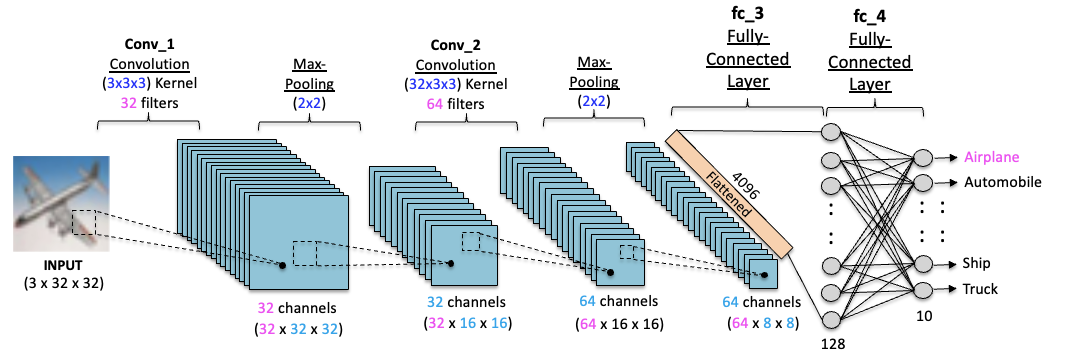

The CIFAR-10 dataset is a widely used collection of images that is commonly used to train machine learning and computer vision algorithms

It consists of 60,000 32x32 color images in 10 different classes
Each class contains 6,000 images, with 5,000 images for training and 1,000 images for testing
The 10 different classes in the CIFAR-10 dataset represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks
The CIFAR-10 dataset can be split into training set, validation set, and test set in various ways. In this example, the way is to use 45,000 images for training, 5,000 images for validation, and 10,000 images for testing.

References:

https://github.com/nestorojeda/CIFAR-10-CNN

In [ ]:
# Cleanup previous runs
!rm -rf Models
# Change to ROCM backend for faster training
#!pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/rocm6.4

In [ ]:
#!wget https://raw.githubusercontent.com/wiki/ROCm/pytorch/files/install_kdb_files_for_pytorch_wheels.sh
#!chmod +x install_kdb_files_for_pytorch_wheels.sh
#!export GFX_ARCH=gfx1030 && export ROCM_VERSION=6.4.2 && ./install_kdb_files_for_pytorch_wheels.sh

## Assignment 2: Summary Report

Provide your assignment report here. Write a summary report of your model architecture design, training process, experimental results, evaluation, and conclusions. Discuss which techniques work well and how you could improve the baseline model. Include relevant visualizations.



## Changes
1. Switch to using a ResNet model
2. Tune the scheduler with a small width to accelerate training, increase the width later to increase capacity.(Total params = Trainable params = 44,530 for width = 8)
3. Added 25% dropouts to prevent overfitting.
4. ~~Added an extra direct residual connection to the resnet model.~~
5. Added extra data augmentation, with the form of cutmix/mixup collate function.
6. Using SGD and CosineAnnealingLR, try to obtain 80% accuracy in 50 epochs.
  *   *observations: 80% accuracy reached with second cycle of cosine annealing, at Epoch 29.*




Increasing width to 32 and adding an additional block, brining total layers to 16:

In [ ]:
# Install the torchinfo package for showing the network architecture information
!pip install torchinfo -qqq

In [ ]:
# Additional package for non-colab docker container
!pip install numpy scikit-learn pandas
#!pip install cupy-rocm-6-4

In [ ]:
# Import the necessary libraries for working with CIFART-10 dataset and PyTorch.
import torch
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import v2
import torch.nn as nn
import torch.nn.functional as F
from torch import nn,optim,no_grad
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torchinfo import summary

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
#import cupy as cp
import pickle
import sys
import time

from torchvision import utils

In [ ]:
# To configure the usage of a GPU (cuda) or MPS (Apple) if either of them is available
has_mps = torch.backends.mps.is_built()
device = "cuda" if torch.cuda.is_available() else "mps" if has_mps else "cpu"
print(f"Python versoin: {sys.version_info.major, sys.version_info.minor, sys.version_info.micro}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
# print(f"Device Name: {torch.cuda.get_device_name(0)}")
# print(f"Arch: {torch.cuda.get_device_properties(0).gcnArchName if hasattr(torch.cuda.get_device_properties(0), 'gcnArchName') else 'N/A'}")
# torch._inductor.config.max_autotune = True

Python versoin: (3, 12, 12)
PyTorch version: 2.9.1+rocm6.4
Device: cpu


In [ ]:
# Set seed for reproducibility
seed = 2418
torch.manual_seed(seed)

# Download CIFAR10 Dataset

This piece of code helps in downloading and managing the training and test data for a model. The training dataset used is called CIFAR-10 and it has 50,000 training samples. The test dataset is divided into two parts: a validation set and a test set, each with 5,000 samples. The data loaders help in providing batches of data from these datasets for the model to train on. The training data consists of batches of images, where each image is a 32 x 32 pixel color image. The corresponding labels indicate the correct class for each image, such as airplanes, cars, birds, cats, etc.


In [ ]:
# Define data transformations for the training and test sets
train_transform = transforms.Compose([
     transforms.RandomHorizontalFlip(p=0.5),
     #transforms.RandomAffine(degrees=(-5, 5), translate=(0.1, 0.1), scale=(0.9, 1.1)),
     transforms.RandAugment(num_ops=8),
     transforms.ToTensor(), # Convert images to tensors
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))]) # Normalize the image data

test_transform = transforms.Compose([
     transforms.ToTensor(), # Convert images to tensors
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))]) # Normalize the image data

# Create the CIFAR10dataset for the training set with 50,000 images
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Create the CIFAR10 dataset for the test set with 10,000 images
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split the original test set into a validation set with 5,000 samples and a test set with 5,000 samples
val_set, test_set = torch.utils.data.random_split(test_dataset, [5000, 5000])

# Define the data loaders for the training, validation, and test sets
#train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
# Add additional data augmentation (cutmix or mixup)
cutmix = v2.CutMix(num_classes=10)
mixup = v2.MixUp(num_classes=10, alpha=1.0)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])
from torch.utils.data import default_collate
def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, collate_fn=collate_fn)

val_loader = torch.utils.data.DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

# Define the classes for the CIFAR-10 dataset
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']





## Visualize image for each class

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.

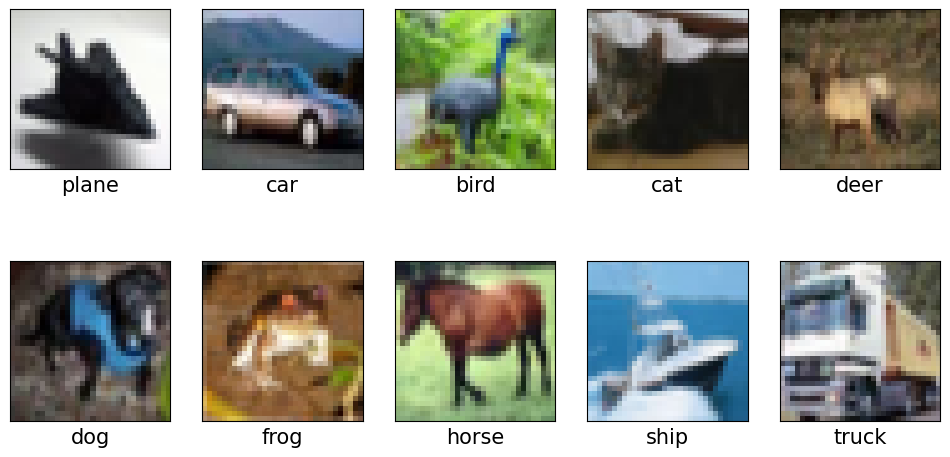

In [ ]:
# Visualize training image for each class
sample_images = [train_set.data[np.asarray(train_set.targets) == label][0] for label in range(10)]
# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel(classes[i], fontsize=15)
    axis.imshow(sample_images[i])
    i += 1

## Define the CNN Architecture

The following code defines a class called CNN_Model which inherits from nn.Module. The network has 2 fully-connected layers:

- In the first line, we use the "Conv2d" module to implement a convolutional neural network. The first parameter, 3, indicates that the input image is colored and in RGB format. If it were a grayscale image, we would use 1 instead.

- The number 32 represents the initial output channels, and in the next Conv2d layer, we would use 32 as the input channels and 64 as the output channels.

- The third parameter in the first line is the kernel size, which determines the size of the filters used. The last parameter is for padding, which helps maintain the spatial dimensions of the input.

After each Conv2d layer, we apply an activation function, specifically the Rectified Linear Unit (ReLU). Following two Conv2d layers, we perform a max-pooling operation with a 2x2 size. The resulting values are then batch normalized to ensure stability and avoid internal covariate shift. These operations are repeated with additional layers to make the network deeper and reduce the size of the data. Finally, we flatten the layer to create a linear layer that maps the values to 10 outputs. The probability of each neuron in these 10 outputs determines the class to which a particular image belongs, with the highest probability indicating the predicted class.

In [ ]:
# Define the CNN Model

class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.drop1 = nn.Dropout(p=0.25)
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.drop2 = nn.Dropout(p=0.25)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.fc1 = nn.Linear(64 * 8 * 8, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x)))
    x = self.pool(torch.relu(self.conv2(x)))
    x = x.view(-1, 64 * 8 * 8) # Flatten the tensor
    x = torch.leaky_relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [ ]:

# Define BasicBlock

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
      super(BasicBlock, self).__init__()

      self.conv1 = nn.Conv2d(
                              in_channels,
                              out_channels,
                              kernel_size=3,
                              stride=stride,
                              padding=1,
                              bias=False)
      self.bn1   = nn.BatchNorm2d(out_channels)
      self.conv2 = nn.Conv2d(
                              out_channels,
                              out_channels,
                              kernel_size=3,
                              stride=1,
                              padding=1,
                              bias=False)
      self.bn2   = nn.BatchNorm2d(out_channels)

      # Use 1x1 conv only when needed to match shape (keeps params low)
      if stride != 1 or in_channels != out_channels:
          self.downsample = nn.Sequential(
              nn.Conv2d(
                              in_channels,
                              out_channels,
                              kernel_size=1,
                              stride=stride,
                              bias=False),
              nn.BatchNorm2d(out_channels)
          )
      else:
        self.downsample = None

    def forward(self, x):
      identity = x

      out = self.conv1(x)
      out = self.bn1(out)
      out = F.silu(out, inplace=True)

      out = self.conv2(out)
      out = self.bn2(out)
      if self.downsample is not None:
        identity = self.downsample(x)
      out = F.silu(out, inplace=True)

      out += identity
      out = F.silu(out)

      return out


class ResNet(nn.Module):
    def __init__(self, num_classes=10):
      super(ResNet, self).__init__()

      # Defining the depth of the model
      num_blocks = [3, 4, 6, 3]

      width = 32 # was: 16
      self.width = width

      # Initial conv: keep channels small to limit parameters
      self.conv1 = nn.Conv2d(
                              3,
                              width,
                              kernel_size=3,
                              stride=1,
                              padding=1,
                              bias=False)
      self.bn1   = nn.BatchNorm2d(width)

      # Three stages: width -> width*2 -> width*4 feature maps
      self.layer1 = self._make_layer(width,   width,    num_blocks[0], stride=1)
      self.layer2 = self._make_layer(width,   width*2,  num_blocks[1], stride=2)
      self.layer3 = self._make_layer(width*2, width*4,  num_blocks[2], stride=2)
      self.layer4 = self._make_layer(width*4, width*8,  num_blocks[2], stride=2)

      # Global average pooling + linear classifier (no big FC stack)
      self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
      self.fc      = nn.Linear(width*4, num_classes)

      self.dropout = nn.Dropout(p=0.25)

      #self.long_skip = nn.Sequential(
      #  nn.Conv2d(3, width*4, kernel_size=1, stride=4, bias=False),  # 32->8
      #  nn.BatchNorm2d(width*4)
      #)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
      strides = [stride] + [1]*(num_blocks-1)
      layers = []
      # First block may change resolution / channels
      # layers.append(BasicBlock(in_channels, out_channels, stride=stride))
      # Remaining blocks keep same channels / resolution
      # Refactor this into easier-to-read code
      for stride in strides:
        layers.append(BasicBlock(in_channels, out_channels, stride=stride))
        in_channels = out_channels
      return nn.Sequential(*layers)

    def forward(self, x):

      long_identity = x
      x = self.conv1(x)
      x = self.bn1(x)
      x = F.silu(x, inplace=True)

      x = self.layer1(x)   # width channels, 32x32
      x = self.dropout(x)
      x = self.layer2(x)   # width*2 channels, 16x16
      x = self.dropout(x)
      x = self.layer3(x)   # width*4 channels, 8x8
      x = self.dropout(x)
      x = self.layer4(x)
      x = self.dropout(x)

      # Long skip: project original input and add
      #long_res = self.long_skip(long_identity)   # 64, 8x8
      #x = x + long_res
      #x = F.leaky_relu(x, inplace=True)

      x = self.avgpool(x)  # 64 x 1 x 1
      x = torch.flatten(x, 1)
      x = self.fc(x)
      return x

In [ ]:
#model = CNN()
model = ResNet()

In [ ]:
summary(model=model, input_size=(1, 3, 32, 32), col_width=15,
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'], verbose=0)

Layer (type (var_name))                  Input Shape     Output Shape    Param #         Trainable
ResNet (ResNet)                          [1, 3, 32, 32]  [1, 10]         1,707,264       True
├─Conv2d (conv1)                         [1, 3, 32, 32]  [1, 16, 32, 32] 432             True
├─BatchNorm2d (bn1)                      [1, 16, 32, 32] [1, 16, 32, 32] 32              True
├─Sequential (layer1)                    [1, 16, 32, 32] [1, 16, 32, 32] --              True
│    └─BasicBlock (0)                    [1, 16, 32, 32] [1, 16, 32, 32] --              True
│    │    └─Conv2d (conv1)               [1, 16, 32, 32] [1, 16, 32, 32] 2,304           True
│    │    └─BatchNorm2d (bn1)            [1, 16, 32, 32] [1, 16, 32, 32] 32              True
│    │    └─Conv2d (conv2)               [1, 16, 32, 32] [1, 16, 32, 32] 2,304           True
│    │    └─BatchNorm2d (bn2)            [1, 16, 32, 32] [1, 16, 32, 32] 32              True
│    └─BasicBlock (1)                    [1, 16, 32, 32

## Training the Network

The steps for training/learning from a batch of data are described in the comments below:

Clear the gradients of all optimized variables
Forward pass: compute predicted outputs by passing inputs to the model
Calculate the loss
Backward pass: compute gradient of the loss with respect to model parameters
Perform a single optimization step (parameter update)
Update average training loss
The following loop trains for 50 epochs; take a look at how the values for the training loss decrease over time. We want it to decrease while also avoiding overfitting the training data.

In [ ]:
# Create a Models folder to store the checkpoints
!mkdir Models

## Specify Loss Function and Optimizer
It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer and then calculates the log loss.

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Cross-Entropy Loss for multi-class classification

# optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
#optimizer = torch.optim.SGD(
#                            model.parameters(),
#                            lr=0.01, momentum=0.9,
#                            weight_decay=5e-4,
#                            nesterov=True)

# Specify Learning Rate Scheduler
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, min_lr=0)


# Use AdamW with proper weight decay
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.01,  # Lower initial learning rate
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  # Initial restart cycle length
    T_mult=2,  # Double cycle length after each restart
    eta_min=1e-6
)

#swa_model = optim.swa_utils.AveragedModel(model)
#swa = optim.swa_utils.SWALR(optimizer, swa_lr=0.001, anneal_epochs=10)
#cos = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)
#
#swa_start = 160
#swa_scheduler = optim.lr_scheduler.ChainedScheduler([swa, cos], optimizer=optimizer)


In [ ]:
def process_labels(labels):
    if len(labels.shape) > 1:  # One-hot encoded
        return torch.argmax(labels, dim=1)
    return labels  # Already class indices

EPOCHS = 500

loss_hist, acc_hist = [], []
loss_hist_val, acc_hist_val = [], []
lr_hist = []

model.to(device)
print(f"Batch shapes - inputs: {batch.shape}, targets: {labels.shape}")
print(f"Model output: {outputs.shape}")
print(f"Expected output: [batch_size, 10] = [{batch.size(0)}, 10]")

print("Training was started.\n")


for epoch in range(1,EPOCHS+1):
  time_ckpt=time.time()
  print("EPOCH:",epoch,end="\t")
  running_loss = 0.0
  correct = 0
  for data in train_loader:
    batch, labels = data
    batch, labels = batch.to(device), labels.to(device)

    # Backwards Pass
    optimizer.zero_grad()
    outputs = model(batch)
    loss = criterion(outputs, process_labels(labels))
    loss.backward()
    # Add Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()


    # compute training statistics
    _, predicted = torch.max(outputs, 1)
    total_samples = labels.size(0)
    correct += (process_labels(labels) == predicted).sum().item()

    running_loss += loss.item()

  avg_loss = running_loss / len(train_set)
  avg_acc = correct / len(train_set)
  loss_hist.append(avg_loss)
  acc_hist.append(avg_acc)

  # validation statistics
  model.eval()
  with torch.no_grad():
    loss_val = 0.0
    correct_val = 0
    for data in val_loader:
      batch, labels = data
      batch, labels = batch.to(device), labels.to(device)
      outputs = model(batch)
      loss = criterion(outputs, process_labels(labels))
      _, predicted = torch.max(outputs, 1)
      correct_val += (process_labels(labels) == predicted).sum().item()
      loss_val += loss.item()

    avg_loss_val = loss_val / len(val_set)
    avg_acc_val = correct_val / len(val_set)
    loss_hist_val.append(avg_loss_val)
    acc_hist_val.append(avg_acc_val)
  model.train()


  #if epoch > swa_start:
  #  swa_model.update_parameters(model)
  #  swa_scheduler.step()
  #else:
  scheduler.step()

  lr_hist.append(optimizer.param_groups[0]['lr'])
  print("LR: {:.4f}".format(optimizer.param_groups[0]['lr']), end=" ")



  print("Training Loss: {:.3f}".format(avg_loss*100),end=" ")
  print("Val Loss: {:.3f}".format(avg_loss_val*100),end=" ")
  print("Train Accuracy: {:.2f}%".format(avg_acc*100),end=" ")
  print("Val Accuracy: {:.2f}%".format(avg_acc_val*100),end=" ")

  with open("Models/cnn_model_{}.pth".format(epoch),"wb") as f:
    model.eval()
    pickle.dump(model,f)
    model.train()

  print("Time: {:.2f}s".format(time.time()-time_ckpt),end=" \n")


Batch shapes - inputs: torch.Size([256, 3, 32, 32]), targets: torch.Size([256, 10])
Model output: torch.Size([256, 10])
Expected output: [batch_size, 10] = [256, 10]
Training was started.

EPOCH: 1	LR: 0.0098 Training Loss: 0.902 Val Loss: 0.837 Train Accuracy: 12.12% Val Accuracy: 20.36% Time: 86.88s 
EPOCH: 2	LR: 0.0090 Training Loss: 0.850 Val Loss: 0.791 Train Accuracy: 18.55% Val Accuracy: 29.28% Time: 86.51s 
EPOCH: 3	LR: 0.0079 Training Loss: 0.821 Val Loss: 0.768 Train Accuracy: 24.17% Val Accuracy: 35.96% Time: 86.76s 
EPOCH: 4	LR: 0.0065 Training Loss: 0.785 Val Loss: 0.672 Train Accuracy: 29.77% Val Accuracy: 44.40% Time: 86.74s 
EPOCH: 5	LR: 0.0050 Training Loss: 0.762 Val Loss: 0.639 Train Accuracy: 33.31% Val Accuracy: 49.62% Time: 86.70s 
EPOCH: 6	LR: 0.0035 Training Loss: 0.737 Val Loss: 0.604 Train Accuracy: 36.36% Val Accuracy: 54.14% Time: 87.07s 
EPOCH: 7	LR: 0.0021 Training Loss: 0.727 Val Loss: 0.562 Train Accuracy: 38.13% Val Accuracy: 58.58% Time: 86.86s 
EPOCH:

## Plotting Training Statistics

Loss is a function of the difference of the network output and the target values. We are minimizing the loss function during training so it should decrease over time. Accuracy is the classification accuracy for the test data.

In [ ]:
plots=[(loss_hist,loss_hist_val),(acc_hist,acc_hist_val),(lr_hist,)]
plt_labels=[("Training Loss","Validation Loss"),("Training Accuracy","Validation Accuracy"),("Learning Rate",)]
plt_titles=["Loss","Accuracy + Learning Rate"]
plt.figure(figsize=(24,8))

# Loss + LR overlay (left subplot) - DUAL Y-AXIS
ax1=plt.subplot(1,2,1)
ax1.plot(plots[0][0],label=plt_labels[0][0], color='tab:blue')
ax1.plot(plots[0][1],label=plt_labels[0][1], color='tab:orange')
ax1.set_title(plt_titles[0])
ax1.set_ylabel("Loss", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Overlay LR on secondary y-axis (right side of Loss plot)
ax1_twin = ax1.twinx()
ax1_twin.plot(plots[2][0], label=plt_labels[2][0], color='tab:red', linewidth=2, alpha=0.8)
ax1_twin.set_ylabel("Learning Rate", color='tab:red')
ax1_twin.tick_params(axis='y', labelcolor='tab:red')
ax1_twin.legend(loc='upper right')

# Accuracy + LR overlay (right subplot) - DUAL Y-AXIS
ax2=plt.subplot(1,2,2)
ax2.plot(plots[1][0],label=plt_labels[1][0], color='tab:blue')
ax2.plot(plots[1][1],label=plt_labels[1][1], color='tab:orange')
ax2.set_title(plt_titles[1])
ax2.set_ylabel("Accuracy", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper left')

# Overlay LR on secondary y-axis (right side)
ax2_twin = ax2.twinx()
ax2_twin.plot(plots[2][0], label=plt_labels[2][0], color='tab:red', linewidth=2, alpha=0.8)
ax2_twin.set_ylabel("Learning Rate", color='tab:red')
ax2_twin.tick_params(axis='y', labelcolor='tab:red')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Save the trained model

In [ ]:
# from google.colab import files
# torch.save(model.state_dict(), 'checkpoint.pth')
# # download checkpoint file
# files.download('checkpoint.pth')
# model.load_state_dict(torch.load('checkpoint.pth'))

In [ ]:
# Selecting the best model
best_acc = max(acc_hist_val)
best_epoch = acc_hist_val.index(best_acc)+1

print("Best accuracy on validation set: {:.2f}%".format(best_acc*100))
print("Best epoch: {}".format(best_epoch))

with open(f"Models/cnn_model_{best_epoch}.pth","rb") as f:
    loaded_model=pickle.load(f)

# Test the Trained Network
Finally, we test our best model on previously unseen test data and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.

In [ ]:
pred_vec = []
label_vec = []
correct = 0
test_loss = 0.0
avg_test_loss = 0.0
model.to(device)

with torch.no_grad():
    for data in test_loader:
        batch, labels = data
        batch, labels = batch.to(device), labels.to(device)
        outputs = model(batch)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        test_loss += loss.item()
        pred_vec.extend(predicted.cpu().numpy())  # Convert tensor to numpy array
        label_vec.extend(labels.cpu().numpy())  # Convert tensor to numpy array

    avg_test_loss = test_loss / len(test_set)

pred_vec = np.array(pred_vec)
label_vec = np.array(label_vec)


# Display the Test Set Accuracy

In [ ]:
print(F"Test Loss: {avg_test_loss}")
print(F"Test Accuracy on the {len(test_set)} test images: {(100 * correct / len(test_set))}%")

# Display the Confusion Matrix

In [ ]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(label_vec, pred_vec)
# Convert confusion matrix to pandas DataFrame
labels = np.unique(label_vec)
confusion_df = pd.DataFrame(confusion_mat, index=classes, columns=classes)
print("Confusion Matrix")
confusion_df

# Compute the Accuracy, F1-Score, Precision, Recall, Support

In [ ]:
# Create a report to show the f1-score, precision, recall
from sklearn.metrics import classification_report

report = pd.DataFrame.from_dict(classification_report(pred_vec,label_vec,output_dict=True)).T
report['Label']=[classes[int(x)] if x.isdigit() else " " for x in report.index]
report=report[['Label','f1-score','precision','recall','support']]
report

In the context of classification, 'support' refers to the number of instances or samples in a dataset that belong to a specific class. It represents the frequency or count of occurrences of each class in the dataset.

Support values help assess the reliability and generalizability of classification models, as they indicate the amount of data available for each class and the potential challenges associated with imbalanced datasets.

# Visualize Sample Test Results
This cell displays test images and their labels in this format: predicted (ground-truth). The text will be green for accurately classified examples and red for incorrect predictions.

In [ ]:
# obtain one batch of test images
images, labels = next(iter(test_loader))
model.cpu()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)

# Create a 4x4 grid for displaying the images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Iterate over the images and display them in the grid
for idx, ax in enumerate(axes.flat):
  # Normalize the image tensor to [0, 1] range
  image = images[idx].permute(1, 2, 0)
  image = (image - image.min()) / (image.max() - image.min())
  ax.imshow(image)  # Display the image
  ax.axis('off')  # Hide the axes
  ax.set_title("{}".format(classes[preds[idx]]),
                 color=("green" if preds[idx]==labels[idx] else "red"))  # Add title to the image
plt.show()

#Display 50 Predicted Images
We iterate through 50 images and plot them with their corresponding label. We will color the label in blue if our model guessed correct and in red if it failed to predict that class.

In [ ]:
# Define the loader for all test data
test_set_all = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)
test_loader_all = torch.utils.data.DataLoader(test_set_all, batch_size=128, shuffle=False, num_workers=2)


# obtain one batch of test images
dataiter = iter(test_loader_all)
images, labels = next(iter(test_loader_all))
model.cpu()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)


fig = plt.figure(figsize=(15, 7))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for idx in range(50):
    # Normalize the image tensor to [0, 1] range
    image = images[idx].permute(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min())
    ax = fig.add_subplot(5, 10, idx + 1, xticks=[], yticks=[])
    ax.imshow(image, interpolation='nearest')

    if preds[idx]==labels[idx]:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='green')
    else:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='red')

plt.show()


## Visualize wrongly classified image for each class

In [ ]:
# Visualize wrongly classified image for each class
pred_vec_all = []
correct = 0
test_loss = 0.0

model.to(device)

with torch.no_grad():
    for data in test_loader_all:
        batch, labels = data
        batch, labels = batch.to(device), labels.to(device)
        outputs = model(batch)
        test_loss=criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec_all.append(predicted)
    pred_vec_all = torch.cat(pred_vec_all)

pred_vec_all = pred_vec_all.cpu().numpy()
ground_truths = np.asarray(test_set_all.targets)
incorrect_mask = pred_vec_all != ground_truths
incorrect_images = [test_set_all.data[(ground_truths == label) & incorrect_mask][0] for label in range(10)]
pred_results_all = [pred_vec_all[(ground_truths == label) & incorrect_mask][0] for label in range(10)]

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel("Predicted: %s" % classes[pred_results_all[i]], fontsize=10)
    axis.imshow(incorrect_images[i], cmap='gray')
    i += 1